In [2]:
%load_ext autoreload
%autoreload 2

import sys
import pandas
sys.path.append("..")
#import pandas
import numpy as np
import matplotlib.pyplot as plt
import warnings
from numpy import random
warnings.filterwarnings('ignore')
import os
from pathlib import Path
from scipy.optimize import curve_fit
datadir0  ='/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures_2026/Fig_Dome/'
datadir1 = '/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures_2026/Fig_Dome/Data/'
plotsdir = '//Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures_2026/Fig_Dome/Plots/'
#dataout  = '/nfs/scistore15/saricgrp/bmeadowc/Scratch/Collagen/model_strict_tetramer/EquilibriumSeededWorkflow/Plotting/'

import sys

# Check the current recursion limit
current_limit = sys.getrecursionlimit()
print("Current recursion limit:", current_limit)

# Increase the recursion limit
sys.setrecursionlimit(6000)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Current recursion limit: 6000


In [3]:
def phiform(phi0,phi_inf,tau,t):
    if tau==0:
        phi = phi_inf
    else:
        phi = (phi0)*np.exp(-t/tau)+phi_inf
    return phi

def intersection(y,y0):
    diff = []
    for i in range(len(y)):
        diff.append(float((y[i]-y0)*(y[i]-y0)))
    diff2 = sorted(diff)
    x = diff.index(diff2[0])
    return x,diff[x]
    
def tolerant_mean(arrs):
    lens = [len(i) for i in arrs]
    #print(lens)
    arr = np.ma.empty((np.max(lens),len(arrs)))
    arr.mask = True
    for idx, l in enumerate(arrs):
        #print(l)
        arr[:len(l),idx] = l
    return arr.mean(axis = -1), arr.std(axis=-1)
# Example function for exponential decay

def exp_decay(t, A, tau, C):
    return A * np.exp(-t / tau) + C

def add_segment(mp_index, t, mean, std):
    """Store one contiguous time segment for a given MP."""
    t = np.asarray(t, dtype=float).copy()
    mean = np.asarray(mean, dtype=float).copy()
    std  = np.asarray(std, dtype=float).copy()
    n = min(len(t), len(mean), len(std))
    if n == 0:
        return
    stress_segments[mp_index].append((t[:n], mean[:n], std[:n]))

def write_mp_file(mp_index, mp_value):
    """Concatenate segments, sort by time, and write a single file."""
    if len(stress_segments[mp_index]) == 0:
        print("No segments for MP", mp_value)
        return

    t_all   = np.concatenate([seg[0] for seg in stress_segments[mp_index]])
    mean_all= np.concatenate([seg[1] for seg in stress_segments[mp_index]])
    std_all = np.concatenate([seg[2] for seg in stress_segments[mp_index]])

    order = np.argsort(t_all)
    df = pandas.DataFrame({
        "Time":      t_all[order],
        "AvStress":  mean_all[order],
        "StdStress": std_all[order],
    })

    # OPTIONAL: if you might have duplicate times (overlap), you can average them:
    # df = df.groupby("Time", as_index=False).agg({"AvStress":"mean", "StdStress":"mean"})

    fname = outdir / f"Stress_MP{mp_value}.dat"
    df.to_csv(fname, sep=" ", index=False, float_format="%.8g")
    print("Wrote", fname)



In [5]:
clrs00 = ['#A10035','#2A0944','lightsalmon','#3FA796','#FEC260','pink','#A10035','#2A0944','#3FA796']
cmap0 = plt.cm.get_cmap('Spectral_r') #YlOrBr
cmap1 = plt.cm.get_cmap('YlOrBr') #YlOrBr
#cmap2 = plt.cm.get_cmap('twilight') #twilight
cmap2 = plt.cm.get_cmap('GnBu') #twilight
cmap3 = plt.cm.get_cmap('BuPu') #twilight
clrs = ['#a6611a','#dfc27d','#80cdc1','#018571','#f5f5f5']
clrs2 = ['#ffffcc','#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#0c2c84','lightsalmon']
clrs3 = ['#c7e9b4','#7fcdbb','#1d91c0','#225ea8','#0c2c84']
clrs = ['#a6611a','#dfc27d','olive','#80cdc1','#018571','steelblue','slateblue','#0c2c84','lightsalmon']
ClrsRiciChosenHalf = ["#7883acff","#73457aff","#b25268ff","#d49995ff"]


In [16]:
def plot_stress_from_files_with_fit(
    MPs,
    clrs,
    outdir,
    ax,
    time_scale=1e5,# ~ tEndRel + 5e5 in your original script
    # plot styling
    lw=2.0,
    alpha_band=0.30,
    # labeling / output
    label_fn=None,          # optional: label_fn(mp_index)->string for mean curve
    annotate_tau=False,     # annotate tau on plot near fit curve
    annotate_fmt=r"$\tau={:.2g}$",
    Z_plot = False,
):
    """
    Reads Stress_MP*.dat (columns: Time AvStress StdStress),
    plots mean with shaded ±std band, and fits exp decay on the mean curve.

    Returns:
        taus: np.array of fitted taus (np.nan if fit failed)
    """
    outdir = Path(outdir)
    taus = np.full(len(MPs), np.nan, dtype=float)

    for x, mp in enumerate(MPs):
        f = outdir / f"Stress_MP{mp}.dat"
        if not f.exists():
            print("Missing:", f)
            continue

        df = pandas.read_csv(f, sep=r"\s+", engine="python")

        # numeric + sorted
        t   = pandas.to_numeric(df["Time"], errors="coerce").to_numpy(dtype=float)
        mu  = pandas.to_numeric(df["AvStress"], errors="coerce").to_numpy(dtype=float)
        sig = pandas.to_numeric(df["StdStress"], errors="coerce").to_numpy(dtype=float)
        muZ  = pandas.to_numeric(df["AvStressZ"], errors="coerce").to_numpy(dtype=float)
        sigZ = pandas.to_numeric(df["StdStressZ"], errors="coerce").to_numpy(dtype=float)

        mask = np.isfinite(t) & np.isfinite(mu) & np.isfinite(sig)
        t, mu, sig = t[mask], mu[mask], sig[mask]
        muZ, sigZ =  muZ[mask], sigZ[mask]
        order = np.argsort(t)
        t, mu, sig, muZ, sigZ = t[order], mu[order], sig[order], muZ[order], sigZ[order]

        # plot mean ± std
        tx = t / time_scale
        lab = None if label_fn is None else label_fn(x)
        if Z_plot:
            ax.plot(tx, muZ, color=clrs[x], linewidth=lw, label=lab)
            ax.fill_between(tx, muZ - sigZ, muZ + sigZ, color=clrs[x], alpha=alpha_band)
        else:
            ax.plot(tx, mu, color=clrs[x], linewidth=lw, label=lab)
            ax.fill_between(tx, mu - sig, mu + sig, color=clrs[x], alpha=alpha_band)

    return taus

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


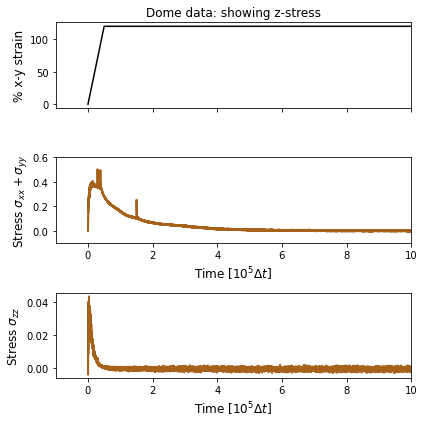

In [22]:
# ---------------- Example usage ----------------
# You already have figNICE, axNICE = plt.subplots(2,1,...)
# and MPs, clrs, datadir0 defined.
#MPs = "0.01 0.03 0.06 0.09 0.18 0.27 0.6 0.81".split() # 0.03 0.06 0.09 0.18 0.27 0.6 0.81
MPs = "0.01 ".split() # 0.18 0.27 0.6 0.81 0.09 0.18 0.27 0.6 0.81 
#MonPref = "9 9 6 6 8 7 11 14".split() # 13 17 26 31   8 6 6 9 9
figNICE,axNICE=plt.subplots(3,1,figsize = (6,6))
outdir = Path(datadir0) / "Data"
clrs = ['#a6611a','#dfc27d','olive','#80cdc1','#018571','steelblue','slateblue','#0c2c84','lightsalmon']
# Optional: if you want the same legend labels you used befor


taus = plot_stress_from_files_with_fit(
    MPs=MPs,
    clrs=clrs,
    outdir=outdir,
    ax=axNICE[2],
    time_scale=1e5,     # set True if you want τ printed on the plot
    Z_plot = True
)

taus = plot_stress_from_files_with_fit(
    MPs=MPs,
    clrs=clrs,
    outdir=outdir,
    ax=axNICE[1],
    time_scale=1e5,     # set True if you want τ printed on the plot
    Z_plot = False
)
text1 = 'Equilibrate'
text2 = 'i. Measure\n   monomer\n   turnover'
text3 = 'ii. Apply strain'
text4 = 'iii. Initial relaxation: \n     no turnover'
text5 = 'Add monomers'
text6 = 'iv. Full relaxation: \n     with turnover'


Times = [0,0.5,6,10]
Strains = [0,120,120,120]
axNICE[0].plot(Times,Strains,linestyle = '-',color = 'black')

axNICE[0].set_ylabel("% x-y strain",fontsize =12)
axNICE[1].set_ylabel("Stress $\sigma_{xx}+\sigma_{yy}$",fontsize = 12)
axNICE[2].set_ylabel("Stress $\sigma_{zz}$",fontsize = 12)
axNICE[1].set_xlabel("Time [$10^5\Delta t$]",fontsize = 12)
axNICE[2].set_xlabel("Time [$10^5\Delta t$]",fontsize = 12)
axNICE[0].set_xticklabels([])
axNICE[1].legend(frameon=False,loc = [0.02,0.3],fontsize = 9,labelspacing=0.12)
axNICE[1].set_xlim([-1,10])
axNICE[0].set_xlim([-1,10])
axNICE[2].set_xlim([-1,10])
axNICE[1].set_ylim([-0.1,0.6])
axNICE[0].set_title("Dome data: showing z-stress")
figNICE.tight_layout()